In [19]:
import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data

nodes_df = pd.read_csv("./pre_processing_output/classification_three_labels_nodes.csv")  # Dataset con nodi (proteine)

nodes_df['GO_embeddings'] = nodes_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.int))

common_nodes = set(nodes_df[nodes_df['label'] == 2]['STRING_id'].to_list())
nodes_df = nodes_df[~nodes_df['STRING_id'].isin(common_nodes)]

G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.long))


data = Data(
    x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
    y=torch.stack([G.nodes[n]['y'] for n in G.nodes])
)

print(data)

Data(x=[167, 200], y=[167])


/tmp/ipykernel_20066/3632037667.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.long))


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np
import torch.optim as optim

class MLP(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, dropout=0):
        super(MLP, self).__init__()

        self.__in_channels = in_channels
        self.__hidden_channels = hidden_channels
        self.__out_channels = out_channels
        self.__dropout = dropout
        
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, out_channels)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x.view(-1)  # Output logits for BCEWithLogitsLoss()
    
    def train_model(self, data, optimizer, criterion, epochs=200, patience=10):
        self.train()
        loss_values = []
        val_loss_values = []
        best_val_loss = float('inf')
        patience_counter = 0

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        for epoch in range(epochs):
            optimizer.zero_grad()
            out = self.forward(data.x)  # Forward pass
            train_loss = criterion(out[data.train_mask], data.y[data.train_mask].float())  # Convert target to float
            train_loss.backward()
            optimizer.step()

            self.eval()
            with torch.no_grad():
                val_out = self.forward(data.x[data.val_mask])
                val_loss = criterion(val_out, data.y[data.val_mask].float())
            self.train()

            loss_values.append(train_loss.item())
            val_loss_values.append(val_loss.item())

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}")
                    break

            if epoch % 10 == 0:
                print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
        # Plot training and validation loss
        plt.figure()
        plt.plot(range(len(loss_values)), loss_values, label='Training Loss')
        plt.plot(range(len(val_loss_values)), val_loss_values, label='Validation Loss', linestyle='dashed')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training & Validation Loss Curve')
        plt.legend()
        plt.show()
    
    def k_fold_cross_validation(self, data, k=5, epochs=100, learning_rate=0.001, patience=10):
        kf = StratifiedKFold(n_splits=k, shuffle=True)
        indices = np.arange(data.x.shape[0])
        best_model = None
        best_f1 = 0
        acc_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
        best_fold_metrics = {}
        best_cm = None

        for fold, (train_idx, val_idx) in enumerate(kf.split(data.x, data.y.cpu().numpy())):
            print(f"\n🔹 Fold {fold+1}/{k}")
            train_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            val_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            train_mask[train_idx] = True
            val_mask[val_idx] = True
            data.train_mask = train_mask
            data.val_mask = val_mask
            data.test_mask = ~train_mask

            model = MLP(in_channels=self.__in_channels, 
                        hidden_channels=self.__hidden_channels, 
                        out_channels=self.__out_channels, 
                        dropout=self.__dropout)
            optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)
            criterion = torch.nn.BCEWithLogitsLoss()
            model.train_model(data, optimizer, criterion, epochs, patience)

            model.eval()
            with torch.no_grad():
                out = model(data.x)
                out = torch.sigmoid(out)  # Apply sigmoid for binary classification
                pred = (out[val_mask] > 0.5).int()
                y_true = data.y[val_mask].cpu().numpy()
                y_pred = pred.cpu().numpy()

                acc = accuracy_score(y_true, y_pred)
                precision = precision_score(y_true, y_pred)
                recall = recall_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred)
                cm = confusion_matrix(y_true, y_pred)

                acc_scores.append(acc)
                precision_scores.append(precision)
                recall_scores.append(recall)
                f1_scores.append(f1)

                print(f"Accuracy: {acc:.4f}")
                print(f"Precision: {precision:.4f}")
                print(f"Recall: {recall:.4f}")
                print(f"F1-Score: {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = model
                    best_fold_metrics = {
                        "Accuracy": acc,
                        "Precision": precision,
                        "Recall": recall,
                        "F1-Score": f1
                    }
                    best_cm = cm

        print("\n📊 **Statistiche medie della K-Fold Cross Validation**")
        print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
        print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
        print(f"Recall: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
        print(f"F1-Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
        
        print("\n📊 **Prestazioni del miglior modello nella sua fold di validazione**")
        for metric, value in best_fold_metrics.items():
            print(f"{metric}: {value:.4f}")
        
        # Plot confusion matrix for best model
        if best_cm is not None:
            plt.figure(figsize=(4,4))
            sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.title("Confusion Matrix of Best Model")
            plt.show()


In [21]:
import torch
import numpy as np

def split_dataset(data, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Divide i nodi del dataset in train, validation e test set.
    
    :param data: Dataset PyTorch Geometric (data.x e data.y)
    :param train_ratio: Percentuale di dati di training
    :param val_ratio: Percentuale di dati di validazione
    :param test_ratio: Percentuale di dati di test
    :return: Dataset con maschere aggiornate
    """
    assert train_ratio + val_ratio + test_ratio == 1, "Le percentuali devono sommare a 1!"

    num_nodes = data.x.shape[0]
    indices = np.arange(num_nodes)
    np.random.shuffle(indices)  # Mischiamo gli indici dei nodi
    
    # Definiamo le dimensioni degli split
    train_size = int(train_ratio * num_nodes)
    val_size = int(val_ratio * num_nodes)
    
    # Creiamo le maschere booleane
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    # Assegniamo gli indici alle rispettive maschere
    train_mask[indices[:train_size]] = True
    val_mask[indices[train_size:train_size + val_size]] = True
    test_mask[indices[train_size + val_size:]] = True

    # Aggiorniamo il dataset con le nuove maschere
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask

    return data


# data = split_dataset(data, 0.8, 0.1, 0.1)


🔹 Fold 1/5
Epoch 0, Train Loss: 0.6532, Val Loss: 0.6070, LR: 0.001000
Epoch 10, Train Loss: 0.3808, Val Loss: 0.5336, LR: 0.001000
Epoch 20, Train Loss: 0.2477, Val Loss: 0.5095, LR: 0.001000
Epoch 30, Train Loss: 0.1682, Val Loss: 0.5300, LR: 0.000500
Early stopping triggered at epoch 31


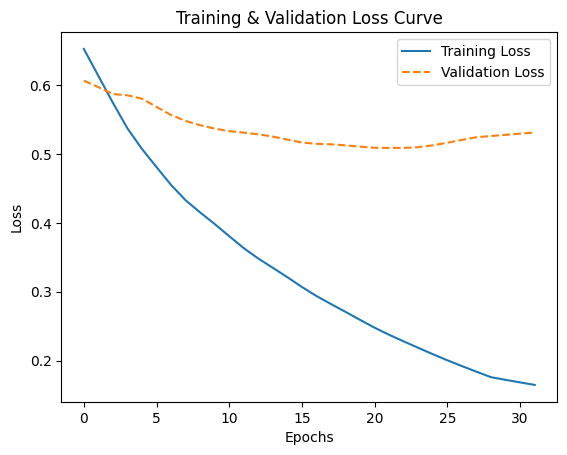

Accuracy: 0.8235
Precision: 0.8462
Recall: 0.7333
F1-Score: 0.7857

🔹 Fold 2/5
Epoch 0, Train Loss: 0.7921, Val Loss: 0.7604, LR: 0.001000
Epoch 10, Train Loss: 0.4758, Val Loss: 0.5777, LR: 0.001000
Epoch 20, Train Loss: 0.3394, Val Loss: 0.4925, LR: 0.001000
Epoch 30, Train Loss: 0.2618, Val Loss: 0.5086, LR: 0.000500
Early stopping triggered at epoch 32


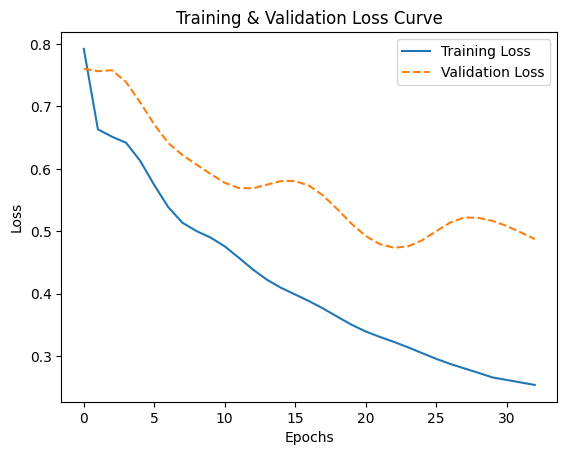

Accuracy: 0.7647
Precision: 1.0000
Recall: 0.4667
F1-Score: 0.6364

🔹 Fold 3/5
Epoch 0, Train Loss: 0.6499, Val Loss: 0.6137, LR: 0.001000
Epoch 10, Train Loss: 0.3782, Val Loss: 0.4875, LR: 0.001000
Epoch 20, Train Loss: 0.2400, Val Loss: 0.4129, LR: 0.001000
Epoch 30, Train Loss: 0.1485, Val Loss: 0.3594, LR: 0.001000
Epoch 40, Train Loss: 0.0901, Val Loss: 0.3306, LR: 0.001000
Epoch 50, Train Loss: 0.0547, Val Loss: 0.3240, LR: 0.001000
Epoch 60, Train Loss: 0.0361, Val Loss: 0.3255, LR: 0.000500
Early stopping triggered at epoch 61


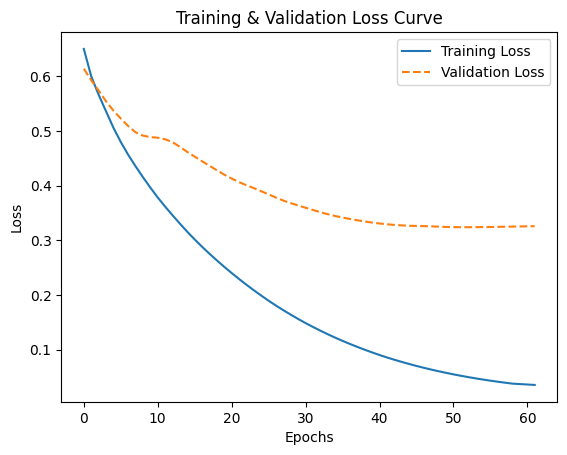

Accuracy: 0.9091
Precision: 0.9286
Recall: 0.8667
F1-Score: 0.8966

🔹 Fold 4/5
Epoch 0, Train Loss: 0.7181, Val Loss: 0.6054, LR: 0.001000
Epoch 10, Train Loss: 0.4493, Val Loss: 0.4386, LR: 0.001000
Epoch 20, Train Loss: 0.3070, Val Loss: 0.3474, LR: 0.001000
Epoch 30, Train Loss: 0.2096, Val Loss: 0.2987, LR: 0.001000
Epoch 40, Train Loss: 0.1458, Val Loss: 0.2735, LR: 0.001000
Epoch 50, Train Loss: 0.1041, Val Loss: 0.2587, LR: 0.001000
Epoch 60, Train Loss: 0.0754, Val Loss: 0.2561, LR: 0.001000
Early stopping triggered at epoch 68


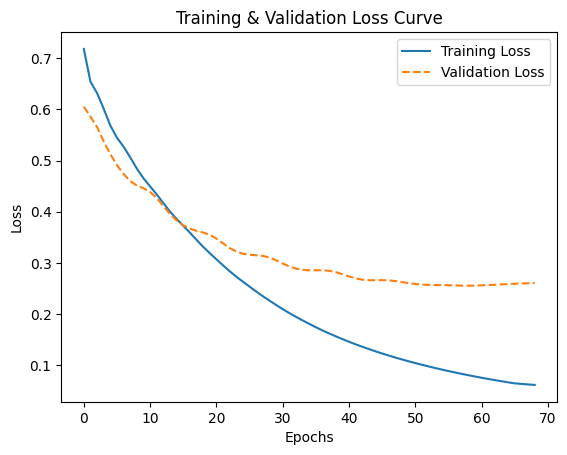

Accuracy: 0.9091
Precision: 0.8750
Recall: 0.9333
F1-Score: 0.9032

🔹 Fold 5/5
Epoch 0, Train Loss: 0.7370, Val Loss: 0.7318, LR: 0.001000
Epoch 10, Train Loss: 0.4159, Val Loss: 0.6946, LR: 0.001000
Early stopping triggered at epoch 19


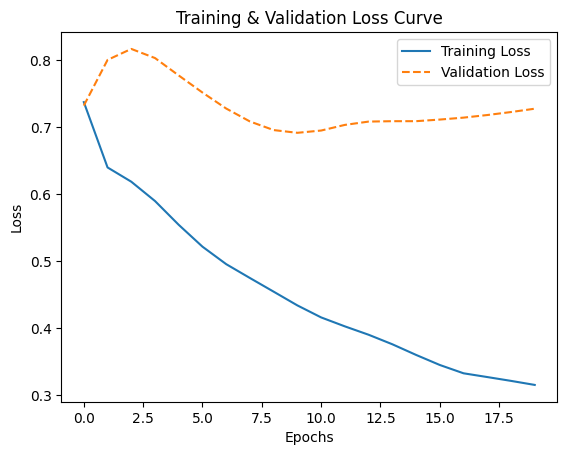

Accuracy: 0.7879
Precision: 0.7857
Recall: 0.7333
F1-Score: 0.7586

📊 **Statistiche medie della K-Fold Cross Validation**
Accuracy: 0.8389 ± 0.0603
Precision: 0.8871 ± 0.0729
Recall: 0.7467 ± 0.1600
F1-Score: 0.7961 ± 0.0986

📊 **Prestazioni del miglior modello nella sua fold di validazione**
Accuracy: 0.9091
Precision: 0.8750
Recall: 0.9333
F1-Score: 0.9032


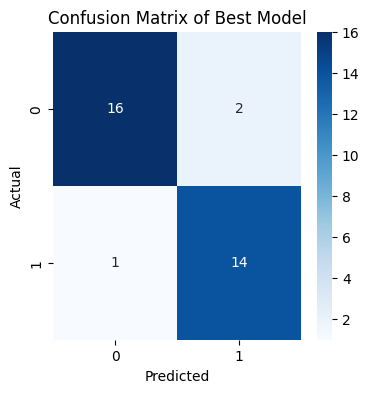

In [22]:
# Train-test split e addestramento
from torch.optim import Adam

KFOLD = True
LR = 0.001

model = MLP(in_channels=data.x.shape[1], hidden_channels=64, out_channels=1, dropout=0)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=5e-4)

if KFOLD:
    model.k_fold_cross_validation(data,epochs=200, learning_rate=LR, patience=10)
else:
    num_nodes = data.x.shape[0]
    train_mask = torch.rand(num_nodes) < 0.8  # 80% training, 20% test
    test_mask = ~train_mask

    data.train_mask = train_mask
    data.test_mask = test_mask

    print(data.y.shape)

    model.train_model(data, optimizer, criterion=nn.BCEWithLogitsLoss(), epochs=500)
    model.test_model(data)